In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

In [2]:
df = pd.read_csv('../data/spy_features.csv', parse_dates=['Date'], index_col='Date')

if 'Next_Day_Return' not in df.columns:
    df['Next_Day_Return'] = df['Daily_Return'].shift(-1)

cols_to_drop = ['High', 'Low', 'Open', 'BB_Middle', 'BB_Lower', 'SMA_20', 'SMA_200', 'EMA_12', 'EMA_26']
df = df.drop(columns=cols_to_drop)
df = df.dropna()

X = df.drop(columns=['Label', 'Next_Day_Return'])
y = df['Label']

tscv = TimeSeriesSplit(n_splits=5)

print(df.columns.tolist())
print(X.shape, y.shape)

['Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'SMA_50', 'ATR', 'OBV', 'Stoch_K', 'Stoch_D', 'Williams_R', 'ROC', 'Label', 'Daily_Return', 'Next_Day_Return']
(2937, 15) (2937,)


In [3]:
def generate_oos_predictions(model, X, y, tscv, scale=False):
    all_dates = []
    all_predictions = []
    all_actuals = []
    all_probabilities = []                                          # NEW

    for train_idx, val_idx in tscv.split(X):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        if scale:
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
        else:
            X_train_scaled = X_train
            X_val_scaled = X_val

        cloned_model = clone(model)
        cloned_model.fit(X_train_scaled, y_train)
        predictions = cloned_model.predict(X_val_scaled)
        probabilities = cloned_model.predict_proba(X_val_scaled)[:, 1]   # NEW

        all_dates.extend(X_val.index)
        all_predictions.extend(predictions)
        all_actuals.extend(y_val)
        all_probabilities.extend(probabilities)                     # NEW

    results_dict = {
        'date': all_dates,
        'prediction': all_predictions,
        'actual': all_actuals,
        'probability': all_probabilities                            # NEW
    }

    oos_df = pd.DataFrame(results_dict)
    oos_df = oos_df.sort_values('date')

    return oos_df

In [4]:
model_configs = {
    'lr_accuracy':  (LogisticRegression(C=0.01, class_weight=None, max_iter=1000, random_state=42), True),
    'lr_recall':    (LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000, random_state=42), True),

    'rf_accuracy':  (RandomForestClassifier(n_estimators=100, max_depth=5, class_weight=None, random_state=42), False),
    'rf_recall':    (RandomForestClassifier(n_estimators=200, max_depth=None, class_weight=None, random_state=42), False),

    'gb_accuracy':  (GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.01, random_state=42), False),
    'gb_recall':    (GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.10, random_state=42), False),

    'hgb_accuracy': (HistGradientBoostingClassifier(class_weight=None, learning_rate=0.01, max_depth=3, max_iter=100, random_state=42), False),
    'hgb_recall':   (HistGradientBoostingClassifier(class_weight='balanced', learning_rate=0.10, max_depth=3, max_iter=100, random_state=42), False),
}

oos_results = {}

for name, (model, scale) in model_configs.items():
    print(f"Running {name}...")
    oos_results[name] = generate_oos_predictions(model, X, y, tscv, scale=scale)

print("Done. Configs generated:", list(oos_results.keys()))

Running lr_accuracy...
Running lr_recall...
Running rf_accuracy...
Running rf_recall...
Running gb_accuracy...
Running gb_recall...
Running hgb_accuracy...
Running hgb_recall...
Done. Configs generated: ['lr_accuracy', 'lr_recall', 'rf_accuracy', 'rf_recall', 'gb_accuracy', 'gb_recall', 'hgb_accuracy', 'hgb_recall']


In [5]:
from sklearn.metrics import recall_score, accuracy_score

for name, single_result in oos_results.items():
    acc = accuracy_score(single_result['actual'], single_result['prediction'])
    rec_down = recall_score(single_result['actual'], single_result['prediction'], pos_label=0)
    print(f"{name}: accuracy={acc:.3f}, recall_down={rec_down:.3f}")

lr_accuracy: accuracy=0.528, recall_down=0.207
lr_recall: accuracy=0.493, recall_down=0.369
rf_accuracy: accuracy=0.495, recall_down=0.561
rf_recall: accuracy=0.482, recall_down=0.664
gb_accuracy: accuracy=0.494, recall_down=0.499
gb_recall: accuracy=0.493, recall_down=0.658
hgb_accuracy: accuracy=0.526, recall_down=0.306
hgb_recall: accuracy=0.479, recall_down=0.595


In [6]:
def compute_equity_curve(oos_df, df):
    # bring in Next_Day_Return by matching on date
    merged = oos_df.merge(df[['Next_Day_Return']], left_on='date', right_index=True, how='left')

    # strategy: earn next day's return only when predicting "up" (1), otherwise sit in cash (0% return)
    merged['strategy_return'] = np.where(merged['prediction'] == 1, merged['Next_Day_Return'], 0)

    # cumulative growth of $1
    merged['strategy_equity'] = (1 + merged['strategy_return']).cumprod()
    merged['buy_hold_equity'] = (1 + merged['Next_Day_Return']).cumprod()

    # Sharpe ratio, annualized, 0% risk-free rate
    strategy_sharpe = (merged['strategy_return'].mean() / merged['strategy_return'].std()) * np.sqrt(252)
    buy_hold_sharpe = (merged['Next_Day_Return'].mean() / merged['Next_Day_Return'].std()) * np.sqrt(252)


    strategy_total_return = merged['strategy_equity'].iloc[-1] - 1
    buy_hold_total_return = merged['buy_hold_equity'].iloc[-1] - 1

    strategy_dd = (merged['strategy_equity'] - merged['strategy_equity'].cummax()) / merged['strategy_equity'].cummax()
    buy_hold_dd = (merged['buy_hold_equity'] - merged['buy_hold_equity'].cummax()) / merged['buy_hold_equity'].cummax()

    metrics = {
        'strategy_sharpe': strategy_sharpe,
        'buy_hold_sharpe': buy_hold_sharpe,
        'strategy_total_return': strategy_total_return,
        'buy_hold_total_return': buy_hold_total_return,
        'strategy_max_drawdown': strategy_dd.min(),
        'buy_hold_max_drawdown': buy_hold_dd.min()
    }

    return merged, metrics


equity_curves = {}
equity_metrics = {}

for name, oos_df in oos_results.items():
    merged, metrics = compute_equity_curve(oos_df, df)
    equity_curves[name] = merged
    equity_metrics[name] = metrics

equity_metrics_df = pd.DataFrame(equity_metrics).T
print(equity_metrics_df)

              strategy_sharpe  buy_hold_sharpe  strategy_total_return  \
lr_accuracy          0.725250         0.875441               1.923694   
lr_recall            0.438824         0.875441               0.732469   
rf_accuracy          0.624067         0.875441               1.182185   
rf_recall            0.488096         0.875441               0.747132   
gb_accuracy          0.481816         0.875441               0.799921   
gb_recall            0.553079         0.875441               0.871941   
hgb_accuracy         0.787946         0.875441               2.153976   
hgb_recall           0.324855         0.875441               0.423558   

              buy_hold_total_return  strategy_max_drawdown  \
lr_accuracy                2.965376              -0.337173   
lr_recall                  2.965376              -0.337173   
rf_accuracy                2.965376              -0.304445   
rf_recall                  2.965376              -0.300748   
gb_accuracy                2.965

None of the 8 configs beat buy-and-hold on Sharpe or total return, confirming finding from earlier. hgb_accuracy came closest (Sharpe 0.788 vs 0.875, smaller drawdown t oo). Winning config per model family locked in for downstream comparisons: lr_accuracy, rf_accuracy, gb_recall, hgb_accuracy.

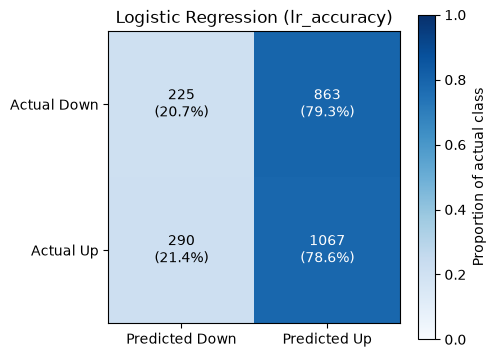

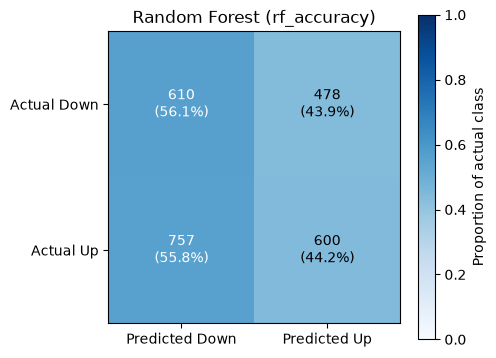

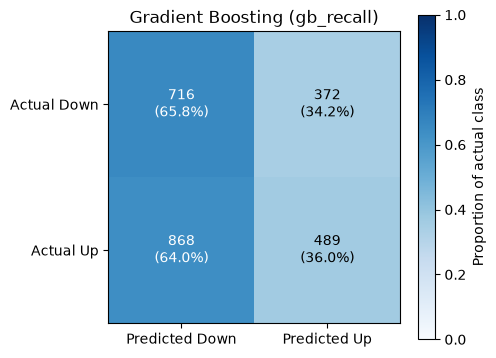

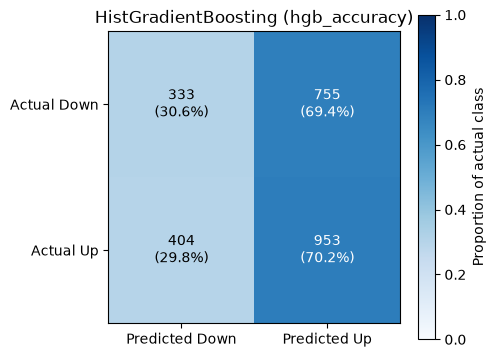

In [7]:
from sklearn.metrics import confusion_matrix

winning_configs = {
    'Logistic Regression': 'lr_accuracy',
    'Random Forest': 'rf_accuracy',
    'Gradient Boosting': 'gb_recall',
    'HistGradientBoosting': 'hgb_accuracy'
}

for model_name, config_key in winning_configs.items():
    result_df = oos_results[config_key]

    cm = confusion_matrix(result_df['actual'], result_df['prediction'])
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    labels = np.array([
        [f"{cm[i, j]}\n({cm_normalized[i, j] * 100:.1f}%)" for j in range(2)]
        for i in range(2)
    ])

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm_normalized, cmap='Blues', vmin=0, vmax=1)

    for i in range(2):
        for j in range(2):
            text_color = 'white' if cm_normalized[i, j] > 0.5 else 'black'
            ax.text(j, i, labels[i, j], ha='center', va='center', color=text_color)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted Down', 'Predicted Up'])
    ax.set_yticklabels(['Actual Down', 'Actual Up'])
    ax.set_title(f'{model_name} ({config_key})')
    plt.colorbar(im, ax=ax, label='Proportion of actual class')
    plt.tight_layout()
    plt.savefig(f'../results/confusion_matrix_{config_key}.png')
    plt.show()

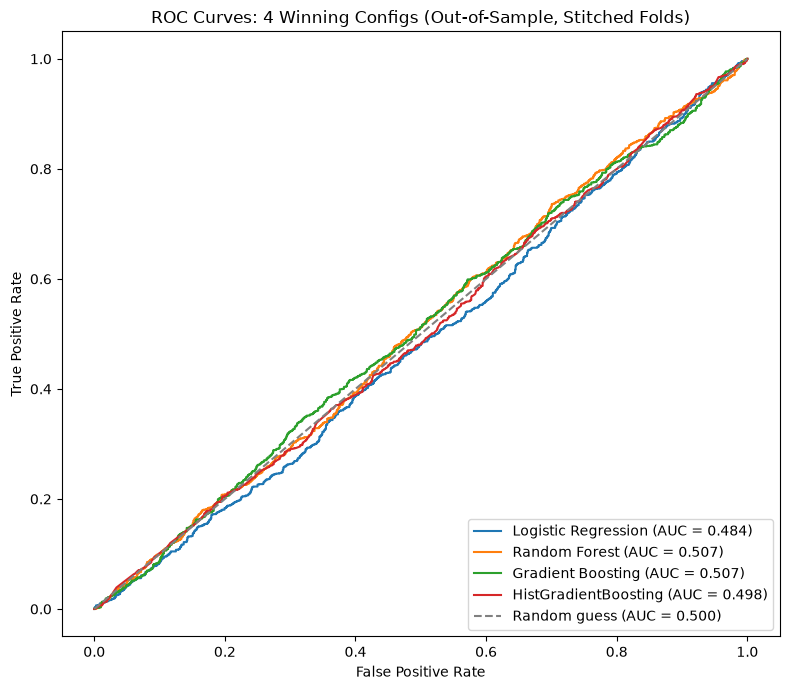

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 7))

for model_name, config_key in winning_configs.items():
    result_df = oos_results[config_key]

    fpr, tpr, thresholds = roc_curve(result_df['actual'], result_df['probability'])
    auc = roc_auc_score(result_df['actual'], result_df['probability'])

    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')

# diagonal reference line: pure coin-flip guessing
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guess (AUC = 0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: 4 Winning Configs (Out-of-Sample, Stitched Folds)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../results/roc_curves_winning_configs.png')
plt.show()

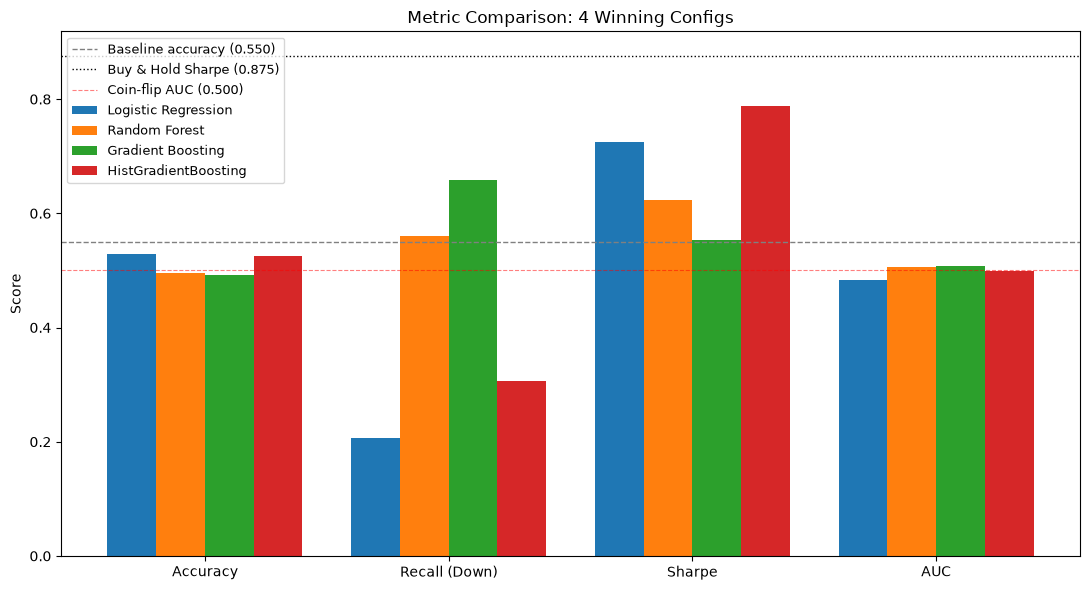

In [9]:
metrics_to_plot = ['Accuracy', 'Recall (Down)', 'Sharpe', 'AUC']

chart_data = {}
for model_name, config_key in winning_configs.items():
    result_df = oos_results[config_key]
    chart_data[model_name] = [
        accuracy_score(result_df['actual'], result_df['prediction']),
        recall_score(result_df['actual'], result_df['prediction'], pos_label=0),
        equity_metrics[config_key]['strategy_sharpe'],
        roc_auc_score(result_df['actual'], result_df['probability'])
    ]

x = np.arange(len(metrics_to_plot))
bar_width = 0.2

fig, ax = plt.subplots(figsize=(11, 6))

for i, (model_name, values) in enumerate(chart_data.items()):
    ax.bar(x + i * bar_width, values, bar_width, label=model_name)

# reference lines
ax.axhline(y=0.550, color='gray', linestyle='--', linewidth=1, label='Baseline accuracy (0.550)')
ax.axhline(y=0.875, color='black', linestyle=':', linewidth=1, label='Buy & Hold Sharpe (0.875)')
ax.axhline(y=0.500, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Coin-flip AUC (0.500)')

ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('Score')
ax.set_title('Metric Comparison: 4 Winning Configs')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../results/metrics_comparison_winning_configs.png')
plt.show()

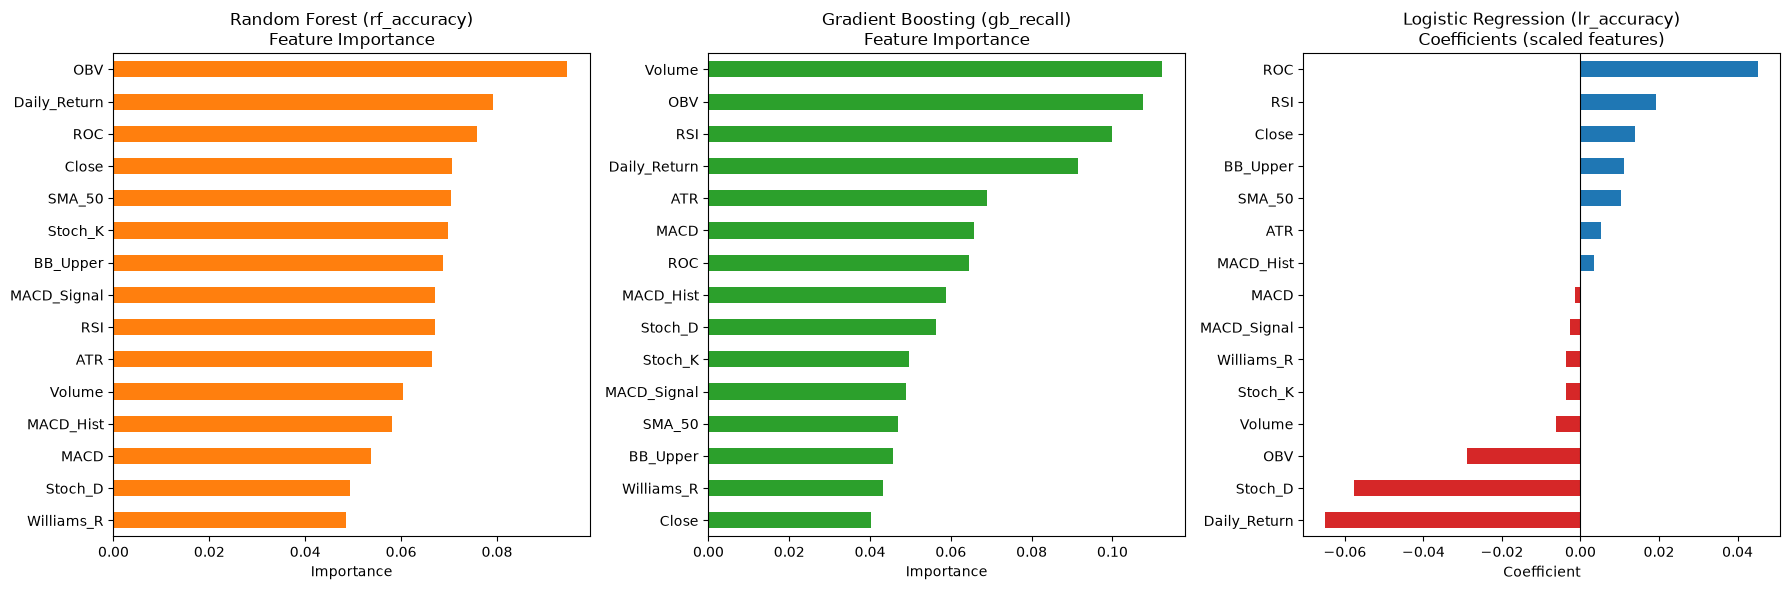

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ---- Random Forest ----
rf_model, _ = model_configs['rf_accuracy']
rf_fitted = clone(rf_model).fit(X, y)
rf_importances = pd.Series(rf_fitted.feature_importances_, index=X.columns).sort_values()

rf_importances.plot(kind='barh', ax=axes[0], color='tab:orange')
axes[0].set_title('Random Forest (rf_accuracy)\nFeature Importance')
axes[0].set_xlabel('Importance')

# ---- Gradient Boosting ----
gb_model, _ = model_configs['gb_recall']
gb_fitted = clone(gb_model).fit(X, y)
gb_importances = pd.Series(gb_fitted.feature_importances_, index=X.columns).sort_values()

gb_importances.plot(kind='barh', ax=axes[1], color='tab:green')
axes[1].set_title('Gradient Boosting (gb_recall)\nFeature Importance')
axes[1].set_xlabel('Importance')

# ---- Logistic Regression coefficients ----
lr_model, _ = model_configs['lr_accuracy']
lr_scaler = StandardScaler()
X_scaled = lr_scaler.fit_transform(X)
lr_fitted = clone(lr_model).fit(X_scaled, y)
lr_coefs = pd.Series(lr_fitted.coef_[0], index=X.columns).sort_values()

colors = ['tab:red' if c < 0 else 'tab:blue' for c in lr_coefs]
lr_coefs.plot(kind='barh', ax=axes[2], color=colors)
axes[2].axvline(x=0, color='black', linewidth=0.8)
axes[2].set_title('Logistic Regression (lr_accuracy)\nCoefficients (scaled features)')
axes[2].set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('../results/feature_importance_winning_configs.png')
plt.show()

In [11]:
import joblib

final_model = HistGradientBoostingClassifier(
    class_weight=None,
    learning_rate=0.01,
    max_depth=3,
    max_iter=100,
    random_state=42
)

final_model.fit(X, y)
joblib.dump(final_model, '../models/hgb_v2.joblib')
print("Saved models/hgb_v2.joblib")

Saved models/hgb_v2.joblib


In [12]:
import json
from datetime import date

with open('../results/metrics.json', 'r') as f:
    metrics = json.load(f)

metrics['selected_model'] = {
    'name': 'hgb_accuracy',
    'model_type': 'HistGradientBoostingClassifier',
    'model_file': 'hgb_v2.joblib',
    'hyperparameters': {
        'class_weight': None,
        'learning_rate': 0.01,
        'max_depth': 3,
        'max_iter': 100,
        'random_state': 42
    },
    'selection_criterion': 'equity curve Sharpe and total return across 8 tuned configs',
    'selection_date': str(date.today())
}

metrics['tuned_config_comparison'] = {}
for name in oos_results:
    result_df = oos_results[name]
    metrics['tuned_config_comparison'][name] = {
        'accuracy': round(accuracy_score(result_df['actual'], result_df['prediction']), 4),
        'recall_down': round(recall_score(result_df['actual'], result_df['prediction'], pos_label=0), 4),
        'auc': round(roc_auc_score(result_df['actual'], result_df['probability']), 4),
        'sharpe': round(equity_metrics[name]['strategy_sharpe'], 4),
        'total_return': round(equity_metrics[name]['strategy_total_return'], 4),
        'max_drawdown': round(equity_metrics[name]['strategy_max_drawdown'], 4)
    }

metrics['buy_and_hold'] = {
    'sharpe': round(equity_metrics['hgb_accuracy']['buy_hold_sharpe'], 4),
    'total_return': round(equity_metrics['hgb_accuracy']['buy_hold_total_return'], 4),
    'max_drawdown': round(equity_metrics['hgb_accuracy']['buy_hold_max_drawdown'], 4)
}

metrics['key_finding'] = (
    'No model across 4 families and 40+ hyperparameter configs beat the 55% '
    'baseline accuracy, buy-and-hold Sharpe, or coin-flip AUC. Selected model '
    'is the best of the set by equity curve metrics, not a model with '
    'demonstrated predictive skill (AUC 0.498).'
)

with open('../results/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics['selected_model'], indent=2))

{
  "name": "hgb_accuracy",
  "model_type": "HistGradientBoostingClassifier",
  "model_file": "hgb_v2.joblib",
  "hyperparameters": {
    "class_weight": null,
    "learning_rate": 0.01,
    "max_depth": 3,
    "max_iter": 100,
    "random_state": 42
  },
  "selection_criterion": "equity curve Sharpe and total return across 8 tuned configs",
  "selection_date": "2026-07-07"
}
